# Analysis on Sexually Transmitted Diseases Morbidity 
## Author: Jasmin Peña 

## Inspiration and Goal 
According to [a 2016 study by the National Institute of Justice (NIJ), more than four in five American Indian and Alaska Native women (84.3%) have experienced violence in their lifetime, including 56.1% who have experienced sexual violence.](https://www.bia.gov/service/mmu/missing-and-murdered-indigenous-people-crisis) When I came across this dataset, I was reminded of that statistic. Hence, this analysis intends to find if this marginalization extends to STD morbidity in Natives and observe how non-Native communities compare to them and each other. 

## About the Data
This dataset was obtained from [CDC WONDER](https://wonder.cdc.gov/), or Centers for Disease Control and Prevention Wide-ranging ONline Data for Epidemiologic Research. CDC WONDER is a menu-driven system that makes information and data from the CDC available to public health professionals and the public at large. </br>
The dataset I will be using for this Jupyter Notebook is [Sexually Transmitted Disease Morbidity:
Selected STDs by Age, Sex, and Race/Ethnicity
United States and Puerto Rico
1996 - 2014 ](https://wonder.cdc.gov/wonder/help/std-race-age-frame.html). It contains case reports of STDS submitted by the state and local health departments. As we will see, the dataset needs to be refined, but the variables most relevant to this analysis are described below: 
1. Disease:  Chlamydia, Gonorrhea, and Primary and Secondary Syphilis (combined)  
2. Race/Ethnicity:  American Indian or Alaskan Native, Asian or Pacific Islander, Black or African American, Hispanic, White
3. Year: 1996 - 2014 
5. Age: Age ranges between 0 and 40 in increments of 5. Past 40, the age range is 40-100
6. STD Cases: incidence count
7. Population: population estimates from National Center for Health Statistics 
8. Rate: calculated as the incidence of STD disease reports, divided by the population, and then the result is multiplied by 100,000 to indicate the rate per so many persons

## Imports


In [73]:
import pandas as pd
import numpy as np 
import matplotlib.pylab as plt

import seaborn as sns
sns.set_theme()

pd.set_option('display.max_columns', 20)

## Getting to Know the Data
Due to the size constraints, the dataset had to be split into multiple parts to download. Here we will be combine them to ease analysis. 

In [74]:
# Reading CSVs to DataFrames
df_1 = pd.read_csv('cdc_std_morbidity_data_AA_hispanic_white.csv')
df_2 = pd.read_csv('cdc_std_morbidity_data_native_asian.csv')

# Ensuring DataFrames were read in properly
df_1.head()

,Notes,Disease,Disease Code,Year,Year Code,Race/Ethnicity,Race/Ethnicity Code,Sex,Sex Code,Age,Age Code,STD Cases,Population,Rate
0,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,0-14 years,0-14,4571.0,4347166,105.15
1,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,15-19 years,15-19,55705.0,1361809,4090.51
2,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,20-24 years,20-24,36920.0,1254149,2943.83
3,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,25-29 years,25-29,12746.0,1312237,971.32
4,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,30-34 years,30-34,4634.0,1420597,326.20


In [75]:
# Concat DataFrames into one single DataFrame
df = pd.concat([df_1, df_2], ignore_index = True)

# See DataFrame
df

,Notes,Disease,Disease Code,Year,Year Code,Race/Ethnicity,Race/Ethnicity Code,Sex,Sex Code,Age,Age Code,STD Cases,Population,Rate
0,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,0-14 years,0-14,4571.0,4347166,105.15
1,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,15-19 years,15-19,55705.0,1361809,4090.51
2,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,20-24 years,20-24,36920.0,1254149,2943.83
3,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,25-29 years,25-29,12746.0,1312237,971.32
4,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,30-34 years,30-34,4634.0,1420597,326.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5396,reports. More information: http://wonder.cdc.g...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5397,10. If the total number of cases in a state in...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5398,all cases of that disease in that state in tha...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5399,for those cases of that disease in that state ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
# DataFrame shape

# Number of row and columns of the DataFrame
print(f'DataFrame Shape: {df.shape}')

DataFrame Shape: (5401, 14)


In [77]:
# First 5 rows of DataFrame
df.head()

,Notes,Disease,Disease Code,Year,Year Code,Race/Ethnicity,Race/Ethnicity Code,Sex,Sex Code,Age,Age Code,STD Cases,Population,Rate
0,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,0-14 years,0-14,4571.0,4347166,105.15
1,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,15-19 years,15-19,55705.0,1361809,4090.51
2,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,20-24 years,20-24,36920.0,1254149,2943.83
3,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,25-29 years,25-29,12746.0,1312237,971.32
4,NaN,Chlamydia,274.0,1996.0,1996.0,Black or African American,2054-5,Female,F,30-34 years,30-34,4634.0,1420597,326.20


In [78]:
# Last 5 rows of DataFrame
df.tail()

,Notes,Disease,Disease Code,Year,Year Code,Race/Ethnicity,Race/Ethnicity Code,Sex,Sex Code,Age,Age Code,STD Cases,Population,Rate
5396,reports. More information: http://wonder.cdc.g...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5397,10. If the total number of cases in a state in...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5398,all cases of that disease in that state in tha...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5399,for those cases of that disease in that state ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5400,http://wonder.cdc.gov/wonder/help/std-race-age...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
# Listing all columns
df.columns

Index(['Notes', 'Disease', 'Disease Code', 'Year', 'Year Code',
       'Race/Ethnicity', 'Race/Ethnicity Code', 'Sex', 'Sex Code', 'Age',
       'Age Code', 'STD Cases', 'Population', 'Rate'],
      dtype='object')

In [80]:
# Data type of each column
df.dtypes

Notes                   object
Disease                 object
Disease Code           float64
Year                   float64
Year Code              float64
Race/Ethnicity          object
Race/Ethnicity Code     object
Sex                     object
Sex Code                object
Age                     object
Age Code                object
STD Cases              float64
Population              object
Rate                    object
dtype: object

In [81]:
# Generic look at numerical data
df.describe()

,Disease Code,Year,Year Code,STD Cases
count,5287.000000,5287.000000,5287.000000,5287.000000
mean,285.044449,2005.308114,2005.308114,3556.689049
std,14.494409,5.400479,5.400479,11665.884615
min,274.000000,1996.000000,1996.000000,1.000000
25%,274.000000,2001.000000,2001.000000,10.000000
50%,280.000000,2005.000000,2005.000000,145.000000
75%,280.000000,2010.000000,2010.000000,1622.500000
max,310.000000,2014.000000,2014.000000,130068.000000


### Analysis
Upon observing the data, here are improvements we are going to make: 
1. Column drops: Drop 'Notes', 'Disease Code', 'State Code', 'Year Code', 'Race/Ethnicity Code', 'Sex Code', and 'Age'. They are obselete and/or hard to work with.
2. Data type changes: 'Population', 'Rate', and 'Age Code' are strings but need to be numerics. 'Year' and 'STD Cases' can be changed to integers to get rid of visual noise.
3. Splits and feature engineering: 'Age Code' will to be spilt into a start and end age range. This will allow more freedom and ease if we analyze age data. 

## Cleaning the Data 

In [82]:
# First let's drop those aforementioned columns. 
df = df[['Disease',  'Year',
       'Race/Ethnicity',  'Sex',
       'Age Code', 'STD Cases', 'Population', 'Rate']]

# List of column of kept names for future use 
column_names = ['Disease',  'Year',
       'Race/Ethnicity',  'Sex',
       'Age Code', 'STD Cases', 'Population', 'Rate']

df.head()

,Disease,Year,Race/Ethnicity,Sex,Age Code,STD Cases,Population,Rate
0,Chlamydia,1996.0,Black or African American,Female,0-14,4571.0,4347166,105.15
1,Chlamydia,1996.0,Black or African American,Female,15-19,55705.0,1361809,4090.51
2,Chlamydia,1996.0,Black or African American,Female,20-24,36920.0,1254149,2943.83
3,Chlamydia,1996.0,Black or African American,Female,25-29,12746.0,1312237,971.32
4,Chlamydia,1996.0,Black or African American,Female,30-34,4634.0,1420597,326.20


In [83]:
# Let's get to know the unique values for each columns
for col in column_names:
    print(f'{col}: {df[col].unique()}')
    print()

# This helps us discern if there are values that need to be dealt with

Disease: ['Chlamydia' 'Gonorrhea' 'Primary and Secondary Syphilis' nan]

Year: [1996. 1997. 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007.
 2008. 2009. 2010. 2011. 2012. 2013. 2014.   nan]

Race/Ethnicity: ['Black or African American' 'Hispanic' 'White' nan
 'American Indian or Alaska Native' 'Asian or Pacific Islander']

Sex: ['Female' 'Male' 'Unknown' nan]

Age Code: ['0-14' '15-19' '20-24' '25-29' '30-34' '35-39' '40+' '99' nan]

STD Cases: [ 4571. 55705. 36920. ...   397.   148.   386.]

Population: ['4347166' '1361809' '1254149' ... '706400' '672943' '3430465']

Rate: ['105.15' '4090.51' '2943.83' ... '10.47' '8.46' '3.26']



In [84]:
# Converting to prefered data types
df = df.assign(
    Population = pd.to_numeric(df['Population'], errors = 'coerce'),
    Rate = pd.to_numeric(df['Rate'], errors = 'coerce'),
)

# Confirming data types changed
df.dtypes

Disease            object
Year              float64
Race/Ethnicity     object
Sex                object
Age Code           object
STD Cases         float64
Population        float64
Rate              float64
dtype: object

In [85]:
# Looking for null values
df.loc[df.isnull().any(axis=1)]

,Disease,Year,Race/Ethnicity,Sex,Age Code,STD Cases,Population,Rate
7,Chlamydia,1996.0,Black or African American,Female,99,1523.0,NaN,NaN
15,Chlamydia,1996.0,Black or African American,Male,99,551.0,NaN,NaN
23,Chlamydia,1996.0,Hispanic,Female,99,687.0,NaN,NaN
31,Chlamydia,1996.0,Hispanic,Male,99,226.0,NaN,NaN
39,Chlamydia,1996.0,White,Female,99,617.0,NaN,NaN
...,...,...,...,...,...,...,...,...
5396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
# Looking for duplicates
df.loc[df.duplicated()]

,Disease,Year,Race/Ethnicity,Sex,Age Code,STD Cases,Population,Rate
3397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
5396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
# We see we have many empty rows. Let's get rid of them 

# Dropping empty rows
df = df.dropna(axis = 0, how = 'all')

# Confirming empty rows were dropped
df.loc[df.duplicated()]

,Disease,Year,Race/Ethnicity,Sex,Age Code,STD Cases,Population,Rate


In [88]:
# Now that there are no rows that are purely NaN values, we can easily turn our 'Year' and 'STD Cases' into the proper data type

# Converting data types 
df['Year'] = df['Year'].astype(int)
df['STD Cases'] = df['STD Cases'].astype(int)

# Confirming data types changed
df.dtypes

Disease            object
Year                int64
Race/Ethnicity     object
Sex                object
Age Code           object
STD Cases           int64
Population        float64
Rate              float64
dtype: object

In [89]:
# We are going to split the age rows into two, 'Age Start' and 'Age End'

# According to documentation, an 'Age' value of 99 is an unknown age. 
# We are going to drop those values
df = df[df['Age Code'] != '99']

# Replace 40+ with 40-100 so that split works uniformly
df['Age Code'] = df['Age Code'].str.replace('40+', '40-100', regex = False)

# Split every row
df[['Age Start', 'Age End']] = df['Age Code']. str.split('-', expand = True)

# Convert new columns to integers
df['Age Start'] = pd.to_numeric(df['Age Start'])
df['Age End'] = pd.to_numeric(df['Age End'])

# Rename 'Age Code' to 'Age' for cleanliness
df.rename(columns = {'Age Code': 'Age'}, inplace = True)

# Confirming data types 
df.dtypes

Disease            object
Year                int64
Race/Ethnicity     object
Sex                object
Age                object
STD Cases           int64
Population        float64
Rate              float64
Age Start           int64
Age End             int64
dtype: object

In [90]:
# One last tidy-up: Will be changing 'Primary and Secondary Syphilis' to 'Syphillis' 
df['Disease'] = df['Disease'].str.replace('Primary and Secondary Syphilis', 'Syphilis', regex = False)

# Once last look at unique values of each column
column_names = ['Disease', 'Year', 'Race/Ethnicity', 'Sex', 'Age', 'STD Cases',
       'Population', 'Rate', 'Age Start', 'Age End']

for col in column_names:
    print(f'{col}: {df[col].unique()}')
    print()


Disease: ['Chlamydia' 'Gonorrhea' 'Syphilis']

Year: [1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009
 2010 2011 2012 2013 2014]

Race/Ethnicity: ['Black or African American' 'Hispanic' 'White'
 'American Indian or Alaska Native' 'Asian or Pacific Islander']

Sex: ['Female' 'Male' 'Unknown']

Age: ['0-14' '15-19' '20-24' '25-29' '30-34' '35-39' '40-100']

STD Cases: [ 4571 55705 36920 ...   148   386    57]

Population: [4347166. 1361809. 1254149. ...  706400.  672943. 3430465.]

Rate: [1.05150e+02 4.09051e+03 2.94383e+03 ... 1.04700e+01 8.46000e+00
 3.26000e+00]

Age Start: [ 0 15 20 25 30 35 40]

Age End: [ 14  19  24  29  34  39 100]



In [91]:
# See disease counts 
df['Disease'].value_counts()

Disease
Chlamydia    1806
Gonorrhea    1700
Syphilis     1246
Name: count, dtype: int64

### Analysis
We have cleaned the data. We have:
1. Reassigned values
2. Deleted duplicates and empty rows left over from drops
3. Split the 'Age Code' column. Note: 100 was used a reasonable ceiling for age ranges 40 years old and up
4. Reassigned data types </br>

It's time to move on to analysis.

## Exploratory Data Analysis

Before we begin, we must be aware of the nature of chlamydia reporting. According to the ['About Chlamydia'](https://wonder.cdc.gov/wonder/help/std-race-age-frame.html#Reporting%20Issues) section in the information page of our dataset: </br>
1. "Before 1996, Chlamydia reporting was voluntary, and thus sporadic. From 1995 - 2000, upstate New York did not report Chlamydia, and thus the total US denominator population for Chlamydia excludes the New York state population for the years 1995 - 2000. However, New York City did report Chlamydia before the year 2000, and the New York City population and Chlamydia cases are included for 1984 - 2000. "
2. "Since Chlamydia is often without symptoms, the number of cases reported is more a function of the amount of screening done and not the actual incidence. Screening occurs more often for women because Chlamydia is associated with Pelvic Inflammatory Disease and infertility. There is approximately a 4:1 ratio of women to men in Chlamydia case reporting due to screening practices." 

Essentially, chlamydia has had inconsistent reporting and must be handled with care and, in some cases, separately from the other STDs. 

### I. Trends Over Time
In this section of exploratory data analysis, we will observe STD cases over time for each disease. This will be done by grouping the data by year and finding the sum of each disease for that year. That DataFrame will then be split further to analyze the diseases on their own. We hope to find meaningful trends of the diseases together and separate.

In [92]:
# Since we will be working with the diseases seperately, we will be making separate DataFrames

# Gonorrhea and Syphilis
df_gon_syph = df[df['Disease'].isin(['Gonorrhea', 'Syphilis'])]

# Gonorrhea 
df_gon = df[df['Disease'] == 'Gonorrhea']

# Syphilis
df_syph = df[df['Disease'] == 'Syphilis']

# Chlamydia
df_chl = df[df['Disease'] == 'Chlamydia']

In [93]:
# Grouping information by 'Year' and 'Disease' and applying sum to 'STD Cases'
# We will be getting the total number of STD cases reported for that year by disease

# Gonorrhea and Syphilis
gon_syph_by_year = df_gon_syph.groupby(['Year', 'Disease'])['STD Cases'].sum().reset_index()

# #Gonorrhea
gon_by_year = gon_syph_by_year[gon_syph_by_year['Disease'] == 'Gonorrhea']

# Syphilis
syph_by_year = gon_syph_by_year[gon_syph_by_year['Disease'] == 'Syphilis']

# Chlamydia
chl_by_year = df_chl.groupby(['Year'])['STD Cases'].sum().reset_index()

# Checking DataFrame to ensure 
gon_by_year.head()

,Year,Disease,STD Cases
0,1996,Gonorrhea,245595
2,1997,Gonorrhea,242821
4,1998,Gonorrhea,276238
6,1999,Gonorrhea,279608
8,2000,Gonorrhea,280169


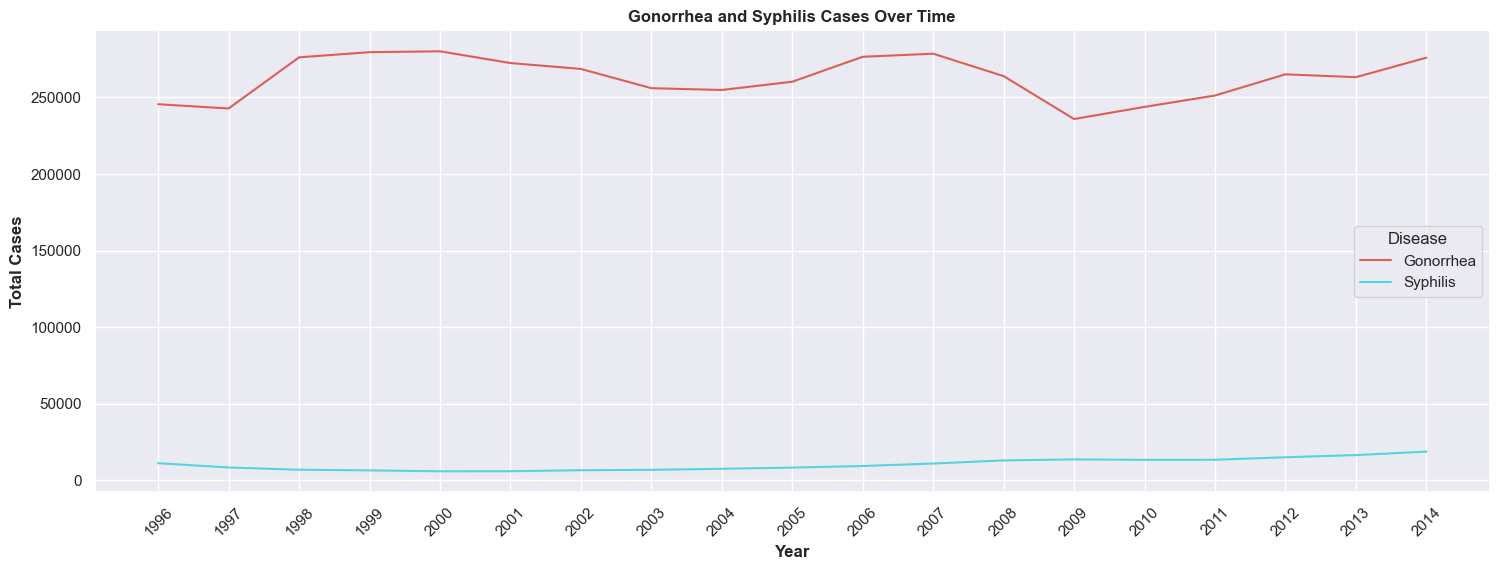

In [94]:
# Comaparing Gonorrhea and Syphilis together to see how they stand against each other

# Plot
plt.figure(figsize = (18,6))

sns.lineplot(data = gon_syph_by_year,
            x = 'Year', 
            y = 'STD Cases',
            palette='hls',
            hue = 'Disease')

# Customizations
plt.xlabel('Year',fontweight = 'bold')
plt.xticks(gon_syph_by_year['Year'].unique(), rotation = 45)
plt.title('Gonorrhea and Syphilis Cases Over Time', fontweight = 'bold')
plt.ylabel('Total Cases',fontweight = 'bold')
plt.show()

**Analysis** </br>
Because there were no discrepancies on how gonorrhea and syphilis were reported, I plotted them together. Upon observation, we see clearly there are *much* more gonorrhea cases reported each year than syphilis. While this lets us see gonorrhea cases remain relatively consistent over the years, syphilis's trend is heavily subdued due to the considerable imbalance in case volume. Plotting the diseases on individual graphs will be necessary to acquire meaningful and accurate data and trends.

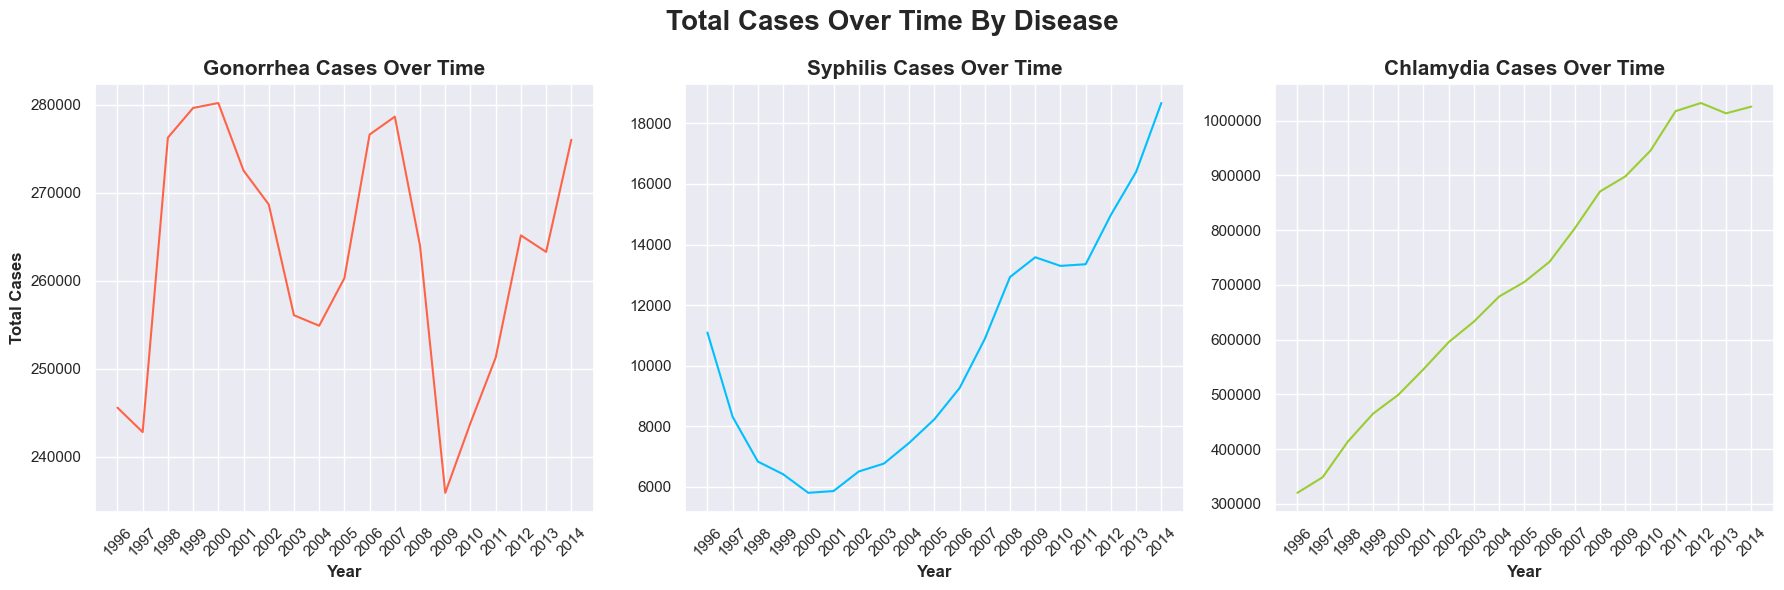

In [95]:
# Diseases on their own plots

# Subplots
fig, axes = plt.subplots(1,3, figsize = (18,6))

# Lists for for loops
disease_names = ['Gonorrhea', 'Syphilis', 'Chlamydia']
color = ['tomato', 'deepskyblue', 'yellowgreen']
my_dfs = [gon_by_year, syph_by_year, chl_by_year, color]

for df, name, color, i in zip(my_dfs, disease_names, color, range(0,3)):
    sns.lineplot(data = df,
                x = 'Year',
                y = 'STD Cases',
                ax = axes[i],
                color = color)
    axes[i].set_title(f'{name} Cases Over Time', 
                      fontsize = 15,
                      fontweight = 'bold')
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Year', fontweight = 'bold')
    axes[i].set_xticks(df['Year'].unique())
    axes[i].tick_params(axis = 'x', rotation = 45)

# Shared ylabel
axes[0].set_ylabel('Total Cases',fontweight = 'bold')

fig.suptitle('Total Cases Over Time By Disease', fontsize = 20, fontweight = 'bold')
plt.ticklabel_format(axis='y', style='plain')
plt.tight_layout()
plt.show()

In [96]:
# Taking a closer look at the spikes and dips 

# Total STD Cases for the year of 2000 and 2009 for gonorrhea
gon_cases_2000 = gon_by_year['STD Cases'].max()
gon_cases_2009 = gon_by_year['STD Cases'].min()

# Printing results and the difference 
print(f'Gonorrhea cases in 2000: {gon_cases_2000}')
print(f'Gonorrhea cases in 2009: {gon_cases_2009}')
print(f'Difference: {gon_cases_2000 - gon_cases_2009}')
print()

# Minimum syphilis cases 
syph_cases_2000 = syph_by_year['STD Cases'].min()
print(f'Syphilis cases in 2000: {syph_cases_2000}')
print()

# Minimum syphilis cases 
chl_cases_2012 = chl_by_year['STD Cases'].max()
print(f'Chlamydia cases in 2000: {chl_cases_2012}')
print()

Gonorrhea cases in 2000: 280169
Gonorrhea cases in 2009: 235928
Difference: 44241

Syphilis cases in 2000: 5807

Chlamydia cases in 2000: 1032089



**Analysis** </br>
Now that there is a zoom up on each diseases' relationship with time, the data reveals some really interesting things! Let's dive into each graph one by one.
* **Gonorrhea**: Compared to our previous graph, gonorrhea's trend looks much more jagged. The graph contains really steep increases and decreases, the highest and lowest being about 280,000 and 236,000, respectively, resulting in a difference of about 44,000 cases. However, when we take a step back and revisit our previous graph, it is clear our new graph is a dramatization. The case reportings at their highest and lowest is still about a quarter of a million cases per year.
* **Syphilis**: Now that syphilis has its own graph, a distinct trend appears. Interestingly, there was a dive in case reportings from 1996 to 2000, where in 2000 there just 5,807 cases! After 2000, unfortunately, they maintain a steady climb back up, more than tripling in reportings by 2014.
* **Chlamydia**: The first thing we notice is, despite documentation explaining chlamydia has a 4:1 woman to man ratio in reportings due to chlamydia screening practices, at its lowest, it still has more reportings than gonorrhea at its highest. It begins to level off in 2013 but by 2014, it climbed to over 1,000,000 reportings that year, about four times more than gonorrhea at, again, its highest.

**Conclusion** </br>
Overall, the graphs illustrate a steady trend in gonorrhea cases and steady climb in syphilis and chlamydia. We will probably see these trends reflected when we analyze by race.

### II. Trends by Race
In this section, we are going to see how the races compare to each other. Because populations may vary significantly, 'Rate' instead of 'STD Cases' will be used to compare the races/ethnicities. This will ensure accurate reporting. There is a particular issue we run into when we use 'Rate' as the measuring factor. [According to documentation](https://wonder.cdc.gov/wonder/help/std-race-age-frame.html#Rates), "rates are not available unless data are grouped by location. Rates are not calculated for Puerto Rico because population denominator data by the race/ethnicity groups in this data set are not available at the time of publication." In short, have to exclude Puerto Rico in this part of our analysis due to missing population data. 

In [97]:
# Checking null values because we will start using 'Rate' instead of 'STD Cases' as the main analyzing factor
print('Checking null values: ')
print(df_gon_syph.isna().sum())
print()
print(df_chl.isna().sum())
print()

# Will be dropping null values for clean, rate-based df
df_gon_syph_rate = df_gon_syph.dropna(subset = ['Rate'])
df_chl_rate = df_chl.dropna(subset = ['Rate'])

# Confirming null values were dropped 
print(f'Checking null values: ')
print(print(df_gon_syph_rate.isna().sum()))

Checking null values: 
Disease             0
Year                0
Race/Ethnicity      0
Sex                 0
Age                 0
STD Cases           0
Population        420
Rate              420
Age Start           0
Age End             0
dtype: int64

Disease             0
Year                0
Race/Ethnicity      0
Sex                 0
Age                 0
STD Cases           0
Population        476
Rate              476
Age Start           0
Age End             0
dtype: int64

Checking null values: 
Disease           0
Year              0
Race/Ethnicity    0
Sex               0
Age               0
STD Cases         0
Population        0
Rate              0
Age Start         0
Age End           0
dtype: int64
None


In [98]:
# Spliting DataFrame to localize diseases 
# Grouping by 'Year' and 'Race/Ethnicity' and applying .mean() to 'Rate'
# This is will give us the rate for each race/ethnicity for each year

# Spliting Gonorrhea, Syphilis, and Chlamydia DataFrame to individual DataFrames and grouping
gon_rate = df_gon_syph_rate[df_gon_syph_rate['Disease'] == 'Gonorrhea'].groupby(['Year', 'Race/Ethnicity'])['Rate'].mean().reset_index()
syph_rate = df_gon_syph_rate[df_gon_syph_rate['Disease'] == 'Syphilis'].groupby(['Year', 'Race/Ethnicity'])['Rate'].mean().reset_index()
chl_rate = df_chl_rate.groupby(['Year', 'Race/Ethnicity'])['Rate'].mean().reset_index()

# Ensuring groupby went well
gon_rate.head()

,Year,Race/Ethnicity,Rate
0,1996,American Indian or Alaska Native,125.785714
1,1996,Asian or Pacific Islander,18.132857
2,1996,Black or African American,983.012857
3,1996,Hispanic,67.215000
4,1996,White,37.265000


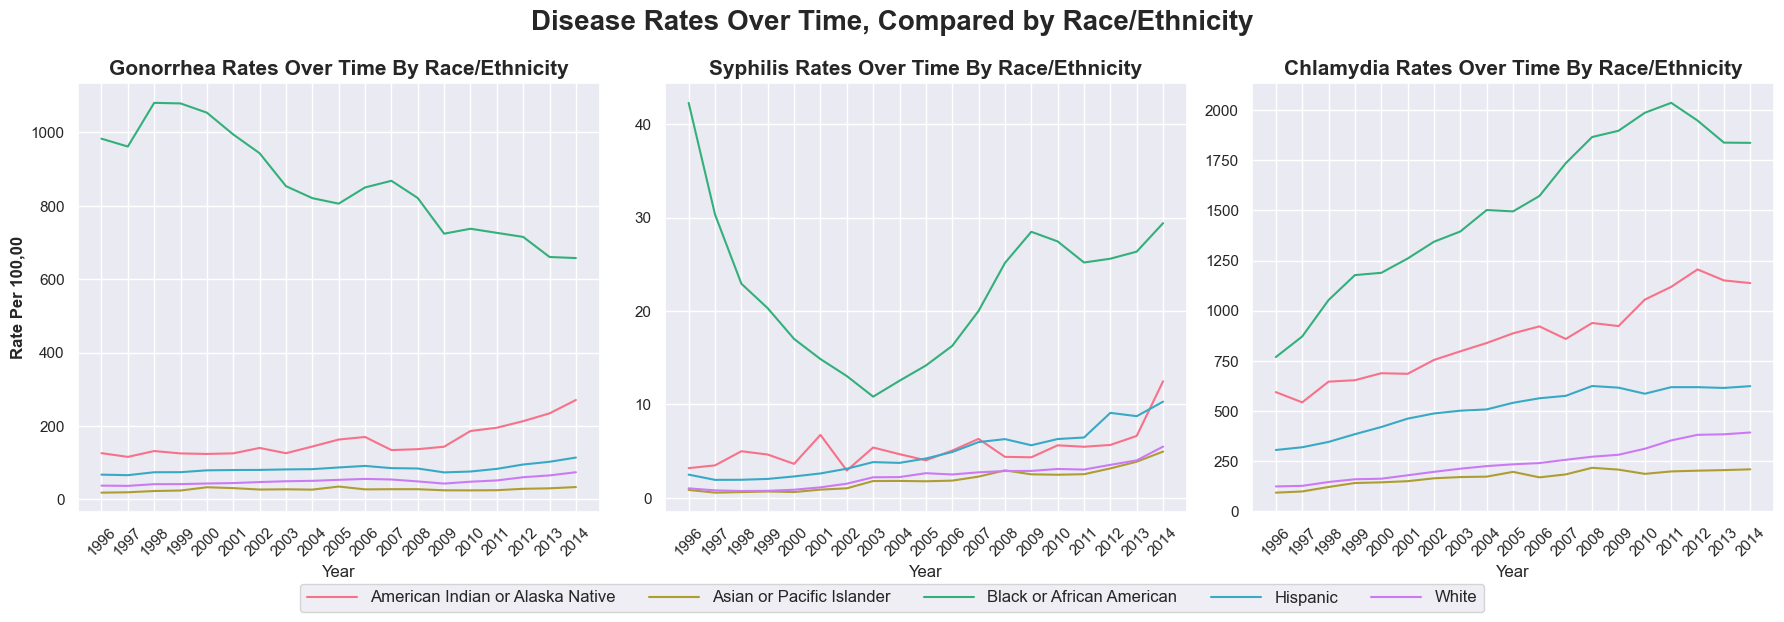

In [99]:
# Gonorrhea, Syphilis, and Chlamydia Subplots

# Subplots
fig, axes = plt.subplots(1,3, figsize = (18, 6))

# Lists to make for loop
my_dfs = [gon_rate, syph_rate, chl_rate]
disease_names = ['Gonorrhea', 'Syphilis', 'Chlamydia']

# for loop to generate subplots
for df, name, i in zip(my_dfs,disease_names, range(0,3)):
    sns.lineplot(data = df,
                x = 'Year',
                y = 'Rate',
                hue = 'Race/Ethnicity',
                palette='husl',
                ax = axes[i])
    axes[i].set_title(f'{name} Rates Over Time By Race/Ethnicity', 
                      fontsize = 15, 
                      fontweight = 'bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('')
    axes[i].set_xticks(df['Year'].unique())
    axes[i].tick_params(axis = 'x', rotation = 45)
    axes[i].get_legend().remove()

# Customizations
axes[0].set_ylabel('Rate Per 100,000',fontweight = 'bold')

fig.suptitle('Disease Rates Over Time, Compared by Race/Ethnicity', fontsize = 20, fontweight = 'bold')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           loc = 'center', 
           ncol = 5, 
           bbox_to_anchor = (0.5, 0),
          fontsize = 12,
          handlelength = 3)

plt.tight_layout()
plt.show()

**Analysis** </br>
This is our first look of how the races/ethnicities compare to each other. The y axis has similar proportions to our **Total Cases Over Time**. It is notable the range of gonorrhea and chlamydia are closer this time, but there are indeed higher rates across all the races/ethnicities for chlamydia. We also see that in all graphs, that while, yes, Native rates are higher in almost all cases, it is massively overshadowed by Black/African American rates. Conversely, Asian/Pacific Islanders keep the lowest rates for all STDs. Let's take a look at each graph individually. </br>
* Gonorrhea: It is apparent here that Native rates are indeed noticeably higher, but are greatly overshadowed by Black/African American rates. Black/African American rates decrease gradually, but there is still an overwhelming difference. In contrast, we see Native rates on the rise. The other races' rates are relatively stagnant in comparison to both.
* Syphilis: Firstly, we can see how low the rate was for syphilis compared the other STDs, with a range of about 0 - 50. Concerning the races, we still see the incredible difference between Black/African American rates and all other races. The huge dive seen in our **Syphilis Cases Over Time** appears to be shaped the impacts of syphilis in Black/African American communities. Native rates are higher than White or Asian/Pacific Islander rates, but the trend line is also noticably intertwined with the trend line for Hispanics. 
* Chlamydia: In this plot, all trend lines are in closer proximity to each other, but there is a significant gaps between the Black/African American, Native, and Hispanic trend lines. Perhaps most notably, it is clear that Hispanic rates are also significantly higher than White and Asian/Pacific Islander. Those two the maintain similar low rates until 2008, where rates for the White population begin to trend upward. </br>

**What's Next** </br>
Because the orginal intent of this project was to see how Native population compare to other races/ethnicities, we are going to calculate an average for Native and non-Native rates and compare them. 

In [100]:
# Comparing Native rates to average rate of all other ethnicites 

# Gonorrhea
gon_native_avg = gon_rate[gon_rate['Race/Ethnicity'] == 'American Indian or Alaska Native']
gon_others_avg = gon_rate[gon_rate['Race/Ethnicity'] != 'American Indian or Alaska Native'].groupby('Year')['Rate'].mean().reset_index()
gon_others_avg['Race/Ethnicity'] = 'Non-Native'
gon_native_vs_others = pd.concat([gon_native_avg, gon_others_avg], ignore_index = True)

# Syphilis
syph_native_avg = syph_rate[syph_rate['Race/Ethnicity'] == 'American Indian or Alaska Native']
syph_others_avg = syph_rate[syph_rate['Race/Ethnicity'] != 'American Indian or Alaska Native'].groupby('Year')['Rate'].mean().reset_index()
syph_others_avg['Race/Ethnicity'] = 'Non-Native'
syph_native_vs_others = pd.concat([syph_native_avg, syph_others_avg], ignore_index = True)

# Chlamydia
chl_native_avg = chl_rate[chl_rate['Race/Ethnicity'] == 'American Indian or Alaska Native']
chl_others_avg = chl_rate[chl_rate['Race/Ethnicity'] != 'American Indian or Alaska Native'].groupby('Year')['Rate'].mean().reset_index()
chl_others_avg['Race/Ethnicity'] = 'Non-Native'
chl_native_vs_others = pd.concat([chl_native_avg, chl_others_avg], ignore_index = True)

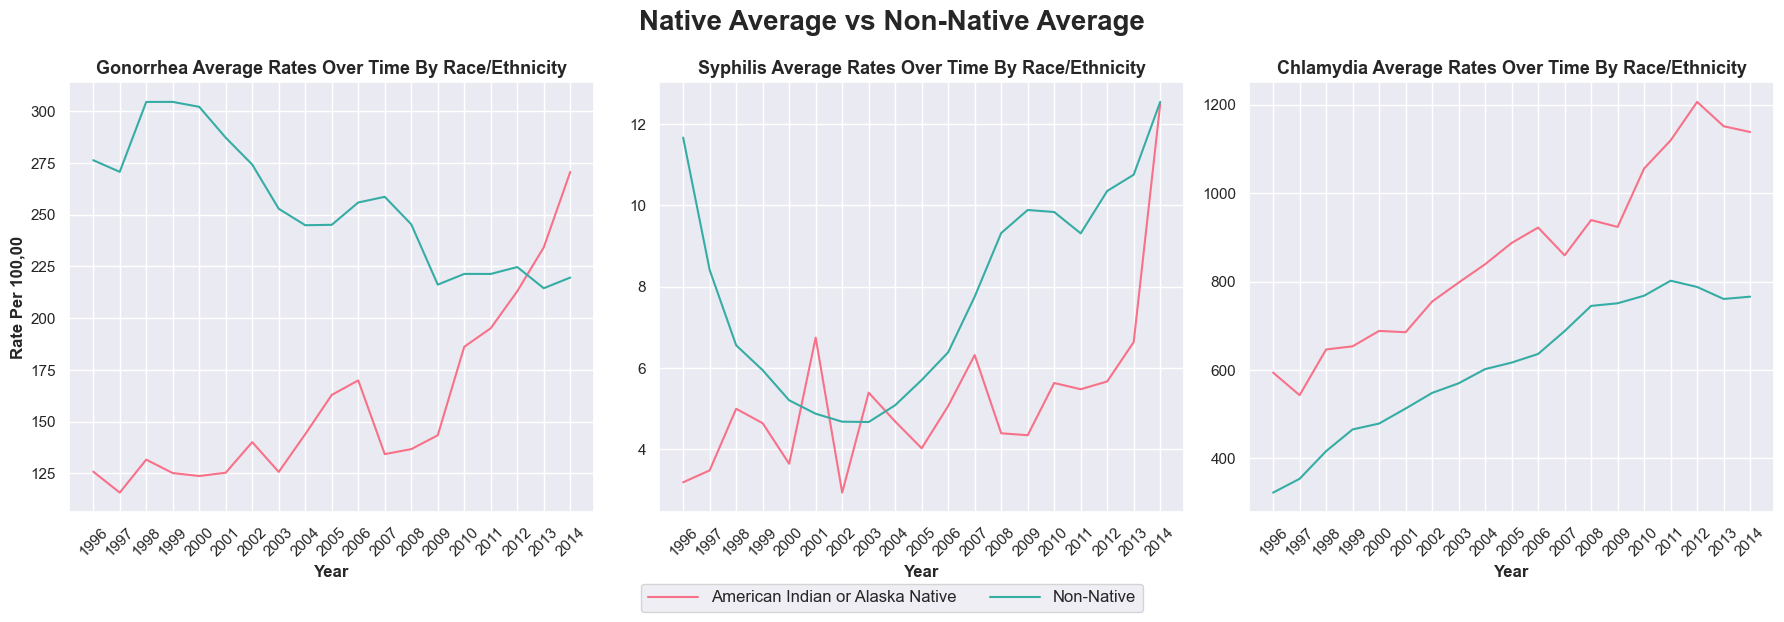

In [101]:
# Gonorrhea, Syphilis, and Chlamydia Subplots

fig, axes = plt.subplots(1,3, figsize = (18, 6))

# Lists to make for loop
my_dfs = [gon_native_vs_others, syph_native_vs_others, chl_native_vs_others]
disease_names = ['Gonorrhea', 'Syphilis', 'Chlamydia']

# for loop to generate subplots
for df, name, i in zip(my_dfs,disease_names, range(0,3)):
    sns.lineplot(data = df,
                x = 'Year',
                y = 'Rate',
                hue = 'Race/Ethnicity',
                palette='husl',
                ax = axes[i])
    axes[i].set_title(f'{name} Average Rates Over Time By Race/Ethnicity', 
                      fontsize = 13, 
                      fontweight = 'bold')
    axes[i].set_xlabel('Year',fontweight = 'bold')
    axes[i].set_ylabel('')
    axes[i].set_xticks(df['Year'].unique())
    axes[i].tick_params(axis = 'x', rotation = 45)
    axes[i].get_legend().remove()

# Customizations 
axes[0].set_ylabel('Rate Per 100,00', fontweight = 'bold')

fig.suptitle('Native Average vs Non-Native Average', fontsize = 20, fontweight = 'bold')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           loc = 'center', 
           ncol = 5, 
           bbox_to_anchor = (0.5, 0),
          fontsize = 12,
          handlelength = 3)

plt.tight_layout()
plt.show()

Now that we ony have 2 trend lines, we can see Native rates much better. </br>
Analyzing the Native rates alone for moment, we see that the trend for gonorrhea and syphilis is very jaggeed but noticeably climbs upward, especially after 2008. Chlamydia maintains a mostly smooth rise in rates throughout the years until it also starts a steep incline in 2008. Looking at the Non-Native trend line, it is evident that Black/African American rates heavily impacted and shaped the rates we are seeing. </br>
Let's look at each graph alone:
* Gonorrhea: It appears the rates are almost the inverse of each other. The gonorrhea average rate starts high and gradually descends with some intermittent increases. The Native average experiences a similar trend but upwards, containing ups and downs, but ultimately by 2013, Native average rates surpass the culumutive average.
* Syphilis: In the cumulative average, the dive we saw in **Syphilis Cases Over Time** and **Syphilis Rates Over Time** is present here as well. We also see the steep rise after the lowest point, though not as even, not present in the Black/African American trend of the previous plot. The Native line shows the sharpest increase in any of the plots from 2013 to 2014. However, when we look at the y axis, the range is from about 2 to 13 per 100,000 relatively small in comparison to the other STDs. Finally, with few exceptions, Native rates consistently remain under the cumulative average until, interestingly, both trend lines meet at the very end. 
* Chlamydia: Here, it is clear that Native rates are higher, and unlike the other graphs, there is no overlap of the trend lines. Both averages experience consistent upward trends, but with a difference of about 300 cases at all times.

**Conclusion** </br>
Because Non-Native rates were so heavily impacted by Black/African American rates, I decided to create an average excluding them to see how Native rates compare to less extreme numbers. 

In [102]:
# Excluding Black/African Americans due to huge discrepancy
# Recycling _Native_avg DataFrames from previous graph 

# Gonorrhea
gon_others_avg2 = gon_rate[gon_rate['Race/Ethnicity'].isin(['Hispanic', 'White', 'Asian or Pacific Islander'])].groupby('Year')['Rate'].mean().reset_index()
gon_others_avg2['Race/Ethnicity'] = 'Hispanic, White, and Asian or Pacific Islander'
gon_native_vs_others2 = pd.concat([gon_native_avg, gon_others_avg2], ignore_index = True)

# Syphilis
syph_others_avg2 = syph_rate[syph_rate['Race/Ethnicity'].isin(['Hispanic', 'White', 'Asian or Pacific Islander'])].groupby('Year')['Rate'].mean().reset_index()
syph_others_avg2['Race/Ethnicity'] = 'Hispanic, White, and Asian or Pacific Islander'
syph_native_vs_others2 = pd.concat([syph_native_avg, syph_others_avg2], ignore_index = True)

# Chlamydia
chl_others_avg2 = chl_rate[chl_rate['Race/Ethnicity'].isin(['Hispanic', 'White', 'Asian or Pacific Islander'])].groupby('Year')['Rate'].mean().reset_index()
chl_others_avg2['Race/Ethnicity'] = 'Hispanic, White, and Asian or Pacific Islander'
chl_native_vs_others2 = pd.concat([chl_native_avg, chl_others_avg2], ignore_index = True)

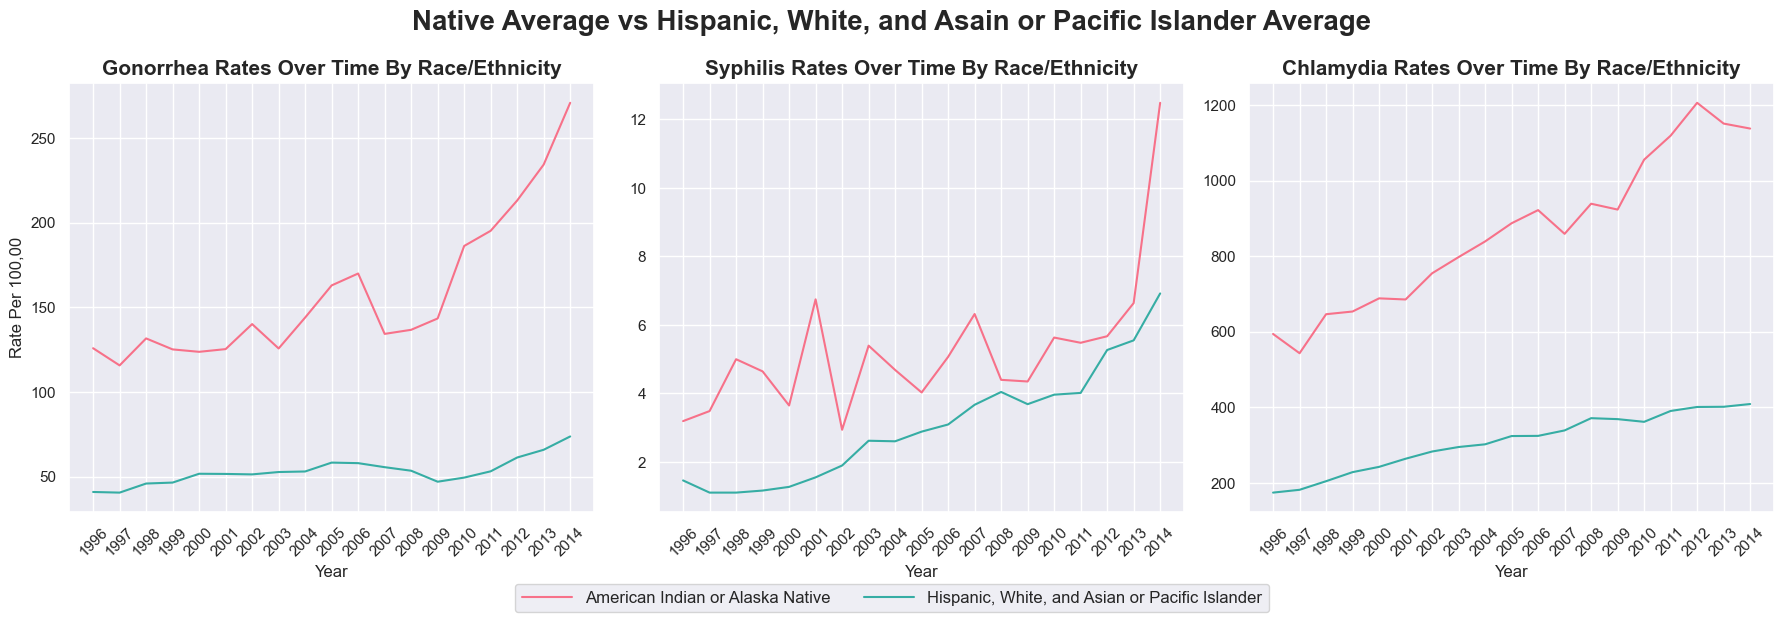

In [103]:
fig, axes = plt.subplots(1,3, figsize = (18, 6))

# Lists to make for loop
my_dfs = [gon_native_vs_others2, syph_native_vs_others2, chl_native_vs_others2]
disease_names = ['Gonorrhea', 'Syphilis', 'Chlamydia']

# for loop to generate subplots
for df, name, i in zip(my_dfs,disease_names, range(0,3)):
    sns.lineplot(data = df,
                x = 'Year',
                y = 'Rate',
                hue = 'Race/Ethnicity',
                palette='husl',
                ax = axes[i])
    axes[i].set_title(f'{name} Rates Over Time By Race/Ethnicity', 
                      fontsize = 15, 
                      fontweight = 'bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('')
    axes[i].set_xticks(df['Year'].unique())
    axes[i].tick_params(axis = 'x', rotation = 45)
    axes[i].get_legend().remove()

# Customizations 
axes[0].set_ylabel('Rate Per 100,00')

fig.suptitle('Native Average vs Hispanic, White, and Asain or Pacific Islander Average', fontsize = 20, fontweight = 'bold')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           loc = 'center', 
           ncol = 5, 
           bbox_to_anchor = (0.5, 0),
          fontsize = 12,
          handlelength = 3)

plt.tight_layout()
plt.show()

**Analysis**
Now that Black/African American rates are not heavily skewing the data, it is clear that Native rates are consistently higher, and incredibly so for gonorrhea and chlamydia, maintaing about four to six times higher rates. Next, we are going to substantiate those numbers, where we will find numerical data to support our claims. 

### III. Numerical Findings 

In this section, we will collect numerical information. We will find average rate and most common age range for each race. We will also find the disparity ratio from the lowest rate (Asian or Pacific Islander) and disparity ratio from the White population, as [White populations have better access to education and healthcare due to systemic oppression that limits that access to other races/ethnicities](https://www.kff.org/racial-equity-and-health-policy/key-data-on-health-and-health-care-by-race-and-ethnicity/?entry=executive-summary-introduction). 

In [104]:
# Column names for DataFrames that will collect numerical data
num_col_names = ['Race/Ethnicity', 'Average Rate', 'Most Common Age Range']

# Empty DataFrames
num_gon = pd.DataFrame(columns = num_col_names)
num_syph = pd.DataFrame(columns = num_col_names)
num_chl = pd.DataFrame(columns = num_col_names)

# List of DataFrames used for collection
my_num_dfs = [num_gon, num_syph, num_chl]

# List of DataFrames being collected from
my_dfs = [df_gon, df_syph, df_chl]

# Diseases
disease_names = ['Gonorrhea', 'Syphilis', 'Chlamydia']

# Variables 
variables = ['Age', 'Rate', 'Age Start', 'Age End']

# for loop to calculate mean rate for each ethnicity, most common age range, and disparity ratios of and between ethnicities
for my_df, name in zip(my_dfs, disease_names):

    # Average Rate
    temp_rate = my_df.groupby('Race/Ethnicity')['Rate'].mean().reset_index()
    temp_rate.columns = ['Race/Ethnicity', 'Average Rate']
    
    # Mode of Age Range
    temp_age = my_df.groupby('Race/Ethnicity')['Age'].agg(
        lambda x: x.mode()[0]).reset_index()
    temp_age.columns = ['Race/Ethnicity', 'Most Common Age Range']

    # Merge
    result = temp_rate.merge(temp_age, on = 'Race/Ethnicity')
    
    # Calculate Disparity Ratio from lowest rate
    min_rate = result['Average Rate'].min()
    result['Disparity Ratio From Lowest Rate'] = (result['Average Rate'] / min_rate).round(2)

    # Calculate Disparity from White race/ethnicity
    white_rate = result[result['Race/Ethnicity'] == 'White']['Average Rate'].values[0]
    result['Disparity Ratio From White Rate'] = (result['Average Rate'] / white_rate).round(2)
    
    # Save into individual DataFrames
    if name == 'Gonorrhea':
        num_gon = result
    elif name == 'Syphilis':
        num_syph = result
    elif name == 'Chlamydia':
        num_chl = result

# Confirming calculations went well and saved accurately
num_gon

,Race/Ethnicity,Average Rate,Most Common Age Range,Disparity Ratio From Lowest Rate,Disparity Ratio From White Rate
0,American Indian or Alaska Native,158.051391,25-29,5.89,3.18
1,Asian or Pacific Islander,26.845208,20-24,1.00,0.54
2,Black or African American,859.906729,15-19,32.03,17.32
3,Hispanic,82.791466,25-29,3.08,1.67
4,White,49.648534,15-19,1.85,1.00


In [105]:
# Combining all calculations for each race/ethnicity into one DataFrame

# Adding 'Disease' column for presentaion
num_gon['Disease'] = 'Gonorrhea'
num_syph['Disease'] = 'Syphilis'
num_chl['Disease'] = 'Chlamydia'

# Master DataFrame
num_summary = pd.concat([num_gon, num_syph, num_chl], ignore_index = True )

# Reorder columns for clarity
num_summary = num_summary[['Disease', 'Race/Ethnicity', 'Average Rate', 'Disparity Ratio From Lowest Rate',
                           'Disparity Ratio From White Rate', 'Most Common Age Range']]

# Round to 'Average Rate' to nearest 2 decimal places
num_summary['Average Rate'] = num_summary['Average Rate'].round(2)

# Sort by Disease and Rate 
num_summary.sort_values(['Disease', 'Average Rate'], ascending = [True, False])

,Disease,Race/Ethnicity,Average Rate,Disparity Ratio From Lowest Rate,Disparity Ratio From White Rate,Most Common Age Range
12,Chlamydia,Black or African American,1514.73,8.91,6.20,15-19
10,Chlamydia,American Indian or Alaska Native,863.39,5.08,3.54,20-24
13,Chlamydia,Hispanic,511.52,3.01,2.09,15-19
14,Chlamydia,White,244.21,1.44,1.00,15-19
11,Chlamydia,Asian or Pacific Islander,170.08,1.00,0.70,20-24
2,Gonorrhea,Black or African American,859.91,32.03,17.32,15-19
0,Gonorrhea,American Indian or Alaska Native,158.05,5.89,3.18,25-29
3,Gonorrhea,Hispanic,82.79,3.08,1.67,25-29
4,Gonorrhea,White,49.65,1.85,1.00,15-19
1,Gonorrhea,Asian or Pacific Islander,26.85,1.00,0.54,20-24


**Analysis** </br>
We've collected our numerical data into one DataFrame grouped by disease. A distinct order arises across all diseases when rates are sorted. Starting from highest to lowest, it is:
1. Black or African American
2. American Indian or Alaska Native
3. Hispanic
4. White
5. Asian or Pacific Islander

Now, let's go through each disease one by one.
1. Chlamydia: As seen in our previous explorations, chlamydia had the highest case counts. Black/African American populations had the highest rate at ~1514 per 100,000, while Asian/Pacific Islanders having the lowest at ~170 per 100,000. This represents a disparity ratio of about 8.91 between the highest and lowest rates. Compared to White populations, Black/African Americans experienced rates ~9 times higher; Native Americans experienced rates ~5 times higher. This is the closest the disparity rates will be between Black/African Americans and all other races. The age range for chlamydia diagnoses is 15-24.
2. Gonorrhea: Again, Black/African American populations had the highest rate, ~859 per 100,000, and Asian Pacific Islanders with the lowest rate of ~26 per 100,000, making Black/African American rates ~32 rate times higher. White populations had a rate of ~49 per 100,000, making Black/African American and Native rates ~17 and ~3 times, repectively, higher. The age range is 15-29.
3. Syphilis: For syphilis, the data pool is smaller, but remains consistent with disparities in rates. Black/African Americans have a rate of ~22 per 100,000 and Asian/Pacific Islanders a rate of 2 per 100,000, making Black/African American rates 11 times higher. Compared to white populations, who had a similar rate to Asian/Pacific Islanders, 2.33 per 100,000, Black/African American and Native rates were ~10 and ~2 times higher. The age range is 20-40+, the highest of the three diseases. 

## Conclusion
When this analysis began, the expectation was that American or Alaska Native populations would exhibit the most pronounced STD rates. While Native rates were indeed elevated across all three diseases, the data revealed a striking finding - Black or African American populations demonstrated rates over 32 time higher than the lowest recorded rates, representing the most significant disparity in the dataset. Hispanic communities also exhibited marginally higher rates than White or Asian or Pacific Islander populations, suggesting systemic barriers that make healthcare and education harder to access for these communities. </br>
It is worth noting that this is far from the first analysis to examine this same dataset. Rather than diminishing its value, it's encouraging. It reflects a sustained, collective effort to understand and address these disparities through data. </br>
Ultimately, this analysis reinforces that STD morbidity is not distributed equally across racial and ethnic groups, and that these disparities are likely driven by systemic inequities rather than biological differences. Data has a story to tell, and surfacing that story responsibly is the first step towards meaningful change. 